>>> STEP 1: Generating Masks with ResNet-18 + K-Means...


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


Processing 2968 image pairs...


  0%|          | 0/2968 [00:00<?, ?it/s]

------------------------------
CLUSTERING REPORT:
Images with Detected Change: 2968
Images with No Change:       0
------------------------------

>>> STEP 2: Training ResNet-18 Classifier on Pseudo-Labels...


...

Epoch 13 | Loss: 0.1289 | Val IoU: 0.2141 | Val Acc: 0.7108


Epoch 14:   0%|          | 0/371 [00:00<?, ?it/s]

Epoch 14 | Loss: 0.1181 | Val IoU: 0.2114 | Val Acc: 0.6882


Epoch 15:   0%|          | 0/371 [00:00<?, ?it/s]

Epoch 15 | Loss: 0.1081 | Val IoU: 0.2176 | Val Acc: 0.6928


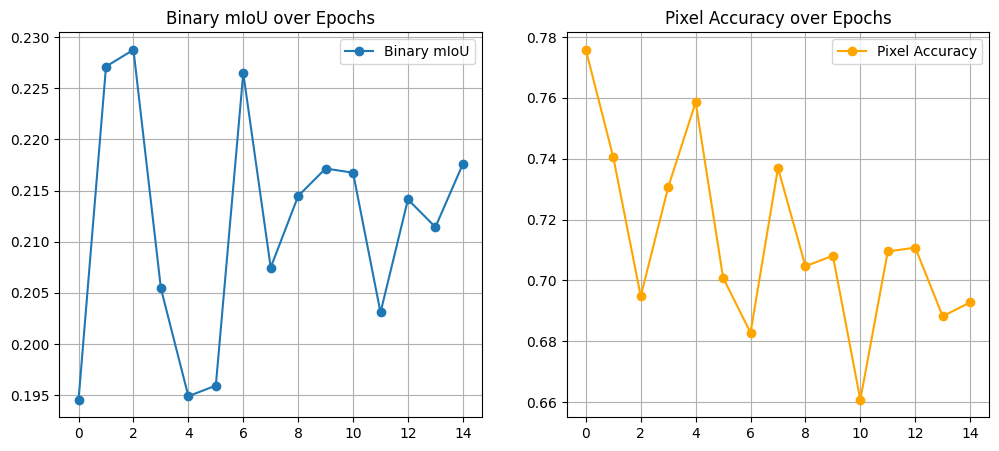

Done! Metrics plot saved.


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# ---------------------------
# CONFIGURATION
# ---------------------------
class Config:
    # Update these paths to match your Kaggle directories
    TRAIN_ROOT = "/kaggle/input/second-dataset-1/SECOND_train_set" 
    TEST_ROOT = "/kaggle/input/second-dataset-testing/SECOND_total_test/test"
    
    # Folder to save the generated pseudo-labels
    PSEUDO_MASK_DIR = "./resnet_pseudo_masks"
    
    # Training Hyperparameters
    EPOCHS = 15
    BATCH_SIZE = 8
    LR = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Clustering Threshold: Min pixels to classify an image as "Changed"
    CHANGE_PIXEL_THRESHOLD = 50 

cfg = Config()
os.makedirs(cfg.PSEUDO_MASK_DIR, exist_ok=True)

# ---------------------------
# 1. FEATURE EXTRACTOR (ResNet-18)
# ---------------------------
class ResNet18FeatExtractor(nn.Module):
    """
    Lightweight feature extractor for Unsupervised Step.
    """
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Use layers up to layer3 for a good balance of semantics and resolution
        self.features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3
        )
        
    def forward(self, x):
        return self.features(x)

def compute_kmeans_mask_resnet(im1_path, im2_path, model, device='cuda'):
    """
    Generates a binary change mask using feature difference + K-Means.
    """
    tf = T.Compose([
        T.Resize((256, 256)), 
        T.ToTensor(), 
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    im1 = tf(Image.open(im1_path).convert("RGB")).unsqueeze(0).to(device)
    im2 = tf(Image.open(im2_path).convert("RGB")).unsqueeze(0).to(device)
    
    with torch.no_grad():
        f1 = model(im1)
        f2 = model(im2)
    
    # 1. Compute Absolute Difference map
    diff = torch.abs(f2 - f1)[0] # [C, H_feat, W_feat]
    
    # 2. Upsample to original resolution (approx 512x512)
    diff_up = F.interpolate(diff.unsqueeze(0), size=(512, 512), mode='bilinear', align_corners=False)[0]
    
    # 3. Prepare for K-Means (Flatten pixels)
    C, H, W = diff_up.shape
    flat = diff_up.permute(1, 2, 0).reshape(-1, C).cpu().numpy()
    
    # Optimization: Subsample pixels if image is large
    if flat.shape[0] > 10000:
        idx = np.random.choice(flat.shape[0], 10000, replace=False)
        sample = flat[idx]
    else:
        sample = flat
        
    # 4. K-Means Clustering (2 Clusters: Change vs No-Change)
    kmeans = KMeans(n_clusters=2, n_init=3, random_state=42).fit(sample)
    labels = kmeans.predict(flat).reshape(H, W)
    
    # 5. Determine which cluster is "Change" (Highest magnitude difference)
    centers = kmeans.cluster_centers_
    magnitudes = np.linalg.norm(centers, axis=1)
    change_cluster = np.argmax(magnitudes)
    
    return (labels == change_cluster).astype(np.uint8)

# ---------------------------
# 2. DATASETS (FIXED)
# ---------------------------
class PseudoLabelDataset(Dataset):
    def __init__(self, img_root, mask_root):
        self.im1_dir = os.path.join(img_root, "im1")
        self.im2_dir = os.path.join(img_root, "im2")
        self.mask_dir = mask_root
        self.ids = sorted([os.path.splitext(f)[0] for f in os.listdir(mask_root) if f.endswith(".png")])
        self.transform = T.Compose([T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]
        im1 = self.transform(Image.open(os.path.join(self.im1_dir, pid + ".png")).convert("RGB"))
        im2 = self.transform(Image.open(os.path.join(self.im2_dir, pid + ".png")).convert("RGB"))
        
        # Load mask (values are 0 and 255)
        mask_np = np.array(Image.open(os.path.join(self.mask_dir, pid + ".png")))
        
        # --- FIX: Convert 255 back to 1 ---
        # Any value > 128 becomes class 1, else class 0
        mask = (mask_np > 128).astype(np.int64)
        
        return im1, im2, torch.from_numpy(mask).long()

class ValidationDataset(Dataset):
    def __init__(self, root):
        self.im1_dir = os.path.join(root, "im1")
        self.im2_dir = os.path.join(root, "im2")
        self.l1_dir = os.path.join(root, "label1")
        self.l2_dir = os.path.join(root, "label2")
        self.ids = sorted([os.path.splitext(f)[0] for f in os.listdir(self.im1_dir)])
        self.transform = T.Compose([T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]
        im1 = self.transform(Image.open(os.path.join(self.im1_dir, pid+".png")).convert("RGB"))
        im2 = self.transform(Image.open(os.path.join(self.im2_dir, pid+".png")).convert("RGB"))
        
        # Ground Truth Logic
        l1 = np.array(Image.open(os.path.join(self.l1_dir, pid+".png")))
        l2 = np.array(Image.open(os.path.join(self.l2_dir, pid+".png")))
        
        # Simplified binary ground truth
        if l1.ndim > 2:
            gt = (l1 != l2).any(axis=2).astype(np.int64)
        else:
            gt = (l1 != l2).astype(np.int64)
            
        return im1, im2, torch.from_numpy(gt).long()

# ---------------------------
# 3. CLASSIFICATION MODEL (ResNet-18 U-Net)
# ---------------------------
class ResNet18UNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        rn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        self.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight[:, :3] = rn.conv1.weight
            self.conv1.weight[:, 3:] = rn.conv1.weight
            
        self.bn1 = rn.bn1
        self.relu = rn.relu
        self.maxpool = rn.maxpool
        self.layer1 = rn.layer1 
        self.layer2 = rn.layer2 
        self.layer3 = rn.layer3 
        self.layer4 = rn.layer4 
        
        self.dec4 = self._conv_block(512 + 256, 256)
        self.dec3 = self._conv_block(256 + 128, 128)
        self.dec2 = self._conv_block(128 + 64, 64)
        self.dec1 = self._conv_block(64, 32)
        self.final = nn.Conv2d(32, num_classes, kernel_size=1)
        
    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        x0 = self.conv1(x)
        x0 = self.bn1(x0)
        x0 = self.relu(x0)
        x1 = self.maxpool(x0)
        x1 = self.layer1(x1) 
        x2 = self.layer2(x1) 
        x3 = self.layer3(x2) 
        x4 = self.layer4(x3) 
        
        u4 = F.interpolate(x4, size=x3.shape[2:], mode='bilinear', align_corners=False)
        d4 = self.dec4(torch.cat([u4, x3], dim=1))
        
        u3 = F.interpolate(d4, size=x2.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([u3, x2], dim=1))
        
        u2 = F.interpolate(d3, size=x1.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([u2, x1], dim=1))
        
        u1 = F.interpolate(d2, size=x.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(u1)
        
        return self.final(d1)

# ---------------------------
# MAIN EXECUTION
# ---------------------------
if __name__ == "__main__":
    
    # --- STEP 1: CLUSTERING ---
    print(">>> STEP 1: Generating Masks with ResNet-18 + K-Means...")
    
    extractor = ResNet18FeatExtractor().to(cfg.DEVICE).eval()
    
    im1_files = sorted(glob.glob(os.path.join(cfg.TRAIN_ROOT, "im1", "*.png")))
    change_count = 0
    no_change_count = 0
    
    print(f"Processing {len(im1_files)} image pairs...")
    
    for p1 in tqdm(im1_files):
        p2 = p1.replace("im1", "im2")
        fname = os.path.basename(p1)
        
        # Check if mask already exists to save time (Optional, remove if you want to re-run always)
        # if os.path.exists(os.path.join(cfg.PSEUDO_MASK_DIR, fname)):
        #     continue

        mask = compute_kmeans_mask_resnet(p1, p2, extractor, cfg.DEVICE)
        
        if np.sum(mask) > cfg.CHANGE_PIXEL_THRESHOLD:
            change_count += 1
        else:
            no_change_count += 1
            
        # Save as image (0, 255)
        Image.fromarray((mask * 255).astype(np.uint8)).save(os.path.join(cfg.PSEUDO_MASK_DIR, fname))
        
    print("-" * 30)
    print(f"CLUSTERING REPORT:")
    print(f"Images with Detected Change: {change_count}")
    print(f"Images with No Change:       {no_change_count}")
    print("-" * 30)
    
    # --- STEP 2: CLASSIFICATION ---
    print("\n>>> STEP 2: Training ResNet-18 Classifier on Pseudo-Labels...")
    
    train_ds = PseudoLabelDataset(cfg.TRAIN_ROOT, cfg.PSEUDO_MASK_DIR)
    val_ds = ValidationDataset(cfg.TEST_ROOT)
    
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    
    model = ResNet18UNet(num_classes=2).to(cfg.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR)
    criterion = nn.CrossEntropyLoss()
    
    history = {'iou': [], 'acc': []}
    
    for epoch in range(cfg.EPOCHS):
        model.train()
        t_loss = 0
        
        for im1, im2, mask in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            im1, im2, mask = im1.to(cfg.DEVICE), im2.to(cfg.DEVICE), mask.to(cfg.DEVICE)
            x = torch.cat([im1, im2], dim=1)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, mask)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            
        # Validation
        model.eval()
        ious, accs = [], []
        with torch.no_grad():
            for im1, im2, gt in val_loader:
                im1, im2, gt = im1.to(cfg.DEVICE), im2.to(cfg.DEVICE), gt.to(cfg.DEVICE)
                out = model(torch.cat([im1, im2], dim=1))
                pred = torch.argmax(out, dim=1)
                
                # Metrics
                inter = (pred & gt).sum().float()
                union = (pred | gt).sum().float()
                ious.append(((inter + 1e-6)/(union + 1e-6)).item())
                accs.append((pred == gt).float().mean().item())
        
        avg_iou = np.mean(ious)
        avg_acc = np.mean(accs)
        history['iou'].append(avg_iou)
        history['acc'].append(avg_acc)
        
        print(f"Epoch {epoch+1} | Loss: {t_loss/len(train_loader):.4f} | Val IoU: {avg_iou:.4f} | Val Acc: {avg_acc:.4f}")

    # --- STEP 3: PLOTTING ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['iou'], marker='o', label='Binary mIoU')
    plt.title("Binary mIoU over Epochs")
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['acc'], marker='o', color='orange', label='Pixel Accuracy')
    plt.title("Pixel Accuracy over Epochs")
    plt.grid(True)
    plt.legend()
    
    plt.savefig("resnet18_pipeline_metrics.png")
    plt.show()
    print("Done! Metrics plot saved.")